# Bayesian Inference — Medical Testing & Sequential Updating

How much should a positive test result change your belief that you have a disease?
The answer depends heavily on how common the disease is — this notebook works through that using Bayes' Theorem.

**Test characteristics:**
- Sensitivity (true positive rate): P(+ | infected) = 0.97
- False positive rate: P(+ | healthy) = 0.05

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Bayes' Theorem

Given a positive test result, the posterior probability of being infected is:

$$P(I|+) = \frac{P(+|I) \cdot P(I)}{P(+|I) \cdot P(I) + P(+|H) \cdot P(H)}$$

The denominator is the total probability of a positive test across both infected and healthy populations.

In [2]:
p_pos_given_infected = 0.97
p_pos_given_healthy  = 0.05

def bayes_update(prior, tpr, fpr):
    """Return posterior P(infected | positive test) given a prior and test rates."""
    p_positive = tpr * prior + fpr * (1 - prior)
    return (tpr * prior) / p_positive

# Sweep over all plausible prior probabilities
priors = np.linspace(0.001, 0.999, 1000)

posterior_1 = bayes_update(priors, p_pos_given_infected, p_pos_given_healthy)
posterior_2 = bayes_update(posterior_1, p_pos_given_infected, p_pos_given_healthy)

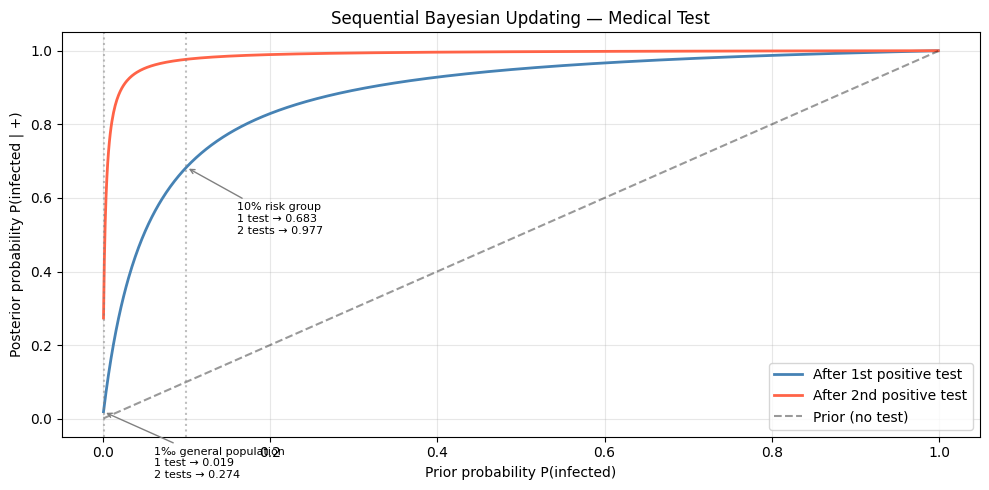

In [3]:
fig, ax = plt.subplots()

ax.plot(priors, posterior_1, label='After 1st positive test', color='steelblue', lw=2)
ax.plot(priors, posterior_2, label='After 2nd positive test', color='tomato', lw=2)
ax.plot(priors, priors, 'k--', alpha=0.4, label='Prior (no test)')

# Annotate two clinically meaningful priors
for prior_val, label in [(0.001, '1‰ general population'), (0.10, '10% risk group')]:
    p1 = bayes_update(prior_val, p_pos_given_infected, p_pos_given_healthy)
    p2 = bayes_update(p1, p_pos_given_infected, p_pos_given_healthy)
    ax.axvline(prior_val, color='gray', linestyle=':', alpha=0.5)
    ax.annotate(
        f'{label}\n1 test → {p1:.3f}\n2 tests → {p2:.3f}',
        xy=(prior_val, p1),
        xytext=(prior_val + 0.06, p1 - 0.18),
        fontsize=8,
        arrowprops=dict(arrowstyle='->', color='gray')
    )

ax.set_xlabel('Prior probability P(infected)')
ax.set_ylabel('Posterior probability P(infected | +)')
ax.set_title('Sequential Bayesian Updating — Medical Test')
ax.legend()
plt.tight_layout()
plt.savefig('bayesian_medical_test.png', dpi=150)
plt.show()

## Results & Interpretation

In [4]:
cases = [
    ('General population', 0.001),
    ('Risk group',         0.100),
]

for label, prior in cases:
    p1 = bayes_update(prior, p_pos_given_infected, p_pos_given_healthy)
    p2 = bayes_update(p1,    p_pos_given_infected, p_pos_given_healthy)
    print(f"{label} (prior = {prior:.1%})")
    print(f"  After 1 positive test : {p1:.4f} ({p1:.1%})")
    print(f"  After 2 positive tests: {p2:.4f} ({p2:.1%})")
    print()

General population (prior = 0.1%)
  After 1 positive test : 0.0190 (1.9%)
  After 2 positive tests: 0.2736 (27.4%)

Risk group (prior = 10.0%)
  After 1 positive test : 0.6831 (68.3%)
  After 2 positive tests: 0.9766 (97.7%)



**Takeaway:** For a rare disease with a 0.1% base rate, a single positive test only raises the probability of infection to ~1.9% — despite a 97% sensitivity. The false positives from the large healthy population dominate. A second positive test pushes this to ~27%.

For the 10% risk group, the same two tests yield ~68% and ~98% respectively — a completely different clinical picture from identical test results.

This is the base rate fallacy in action, and it has direct parallels in ML: a high-accuracy classifier on an imbalanced dataset can still produce mostly false positives.